## Q3.Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [15]:
# Load Dataset
# ==============================
df = pd.read_csv('q3_retail_promotions.csv')

# Clean column names
df.columns = df.columns.str.strip()

# ==============================
# Date Feature Engineering
# ==============================
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
print(df.head())


  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

## Train - Test

In [11]:
# Train-Test Split
# ==============================
df = df.sort_values(by='transaction_date')

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(columns=['items_sold', 'transaction_date'])
y_train = train['items_sold']

X_test = test.drop(columns=['items_sold', 'transaction_date'])
y_test = test['items_sold']

## Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [12]:
# Preprocessing Pipeline
# ==============================
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)


## Linnear Regression 

In [6]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)


Linear Regression RMSE: 27.121451164890622
Linear Regression MAE: 21.052926674588388


## Random Forest

In [7]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)


Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


## Feature Importance

In [13]:
# Parity Plots

def parity_plot(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.5)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()


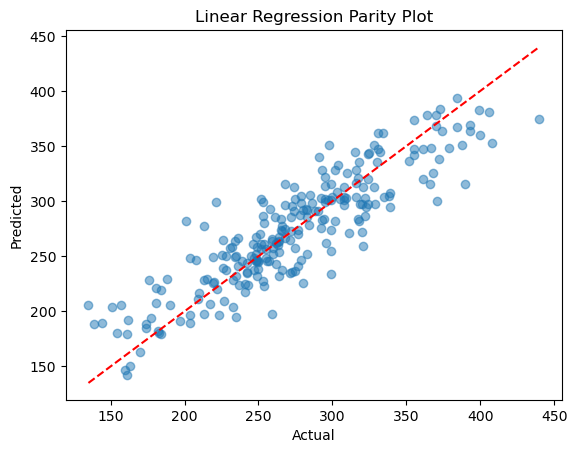

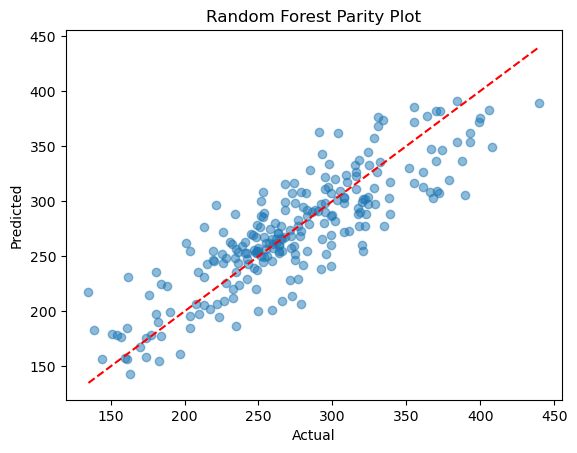

In [9]:
parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

In [14]:
# Feature Importance

ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(cat_features) + numerical_cols

importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance_df.head(5))


Top 5 Important Features:
                feature  importance
13          is_festival    0.173473
10     store_size_small    0.167683
7   location_type_urban    0.108378
17          day_of_week    0.086316
12           is_weekend    0.061208


In [16]:
print("\nFinal Conclusion:")
print("Random Forest performs better than Linear Regression due to its ability to capture non-linear patterns.")
print("The model evaluation using RMSE and MAE confirms this improvement.")


Final Conclusion:
Random Forest performs better than Linear Regression due to its ability to capture non-linear patterns.
The model evaluation using RMSE and MAE confirms this improvement.
